# Run `Test.xlsm` and display the generated chart

This notebook writes user-provided values into `NormalTest!B1`, runs the workbook VBA macro `GenerateNormalData`, reads the generated sample table from columns `C:D`, exports the existing Excel chart `NormalDataChart` as a PNG, and renders both inline.

Requirements:
- Microsoft Excel for Mac is installed.
- Macros are enabled when the copied workbook opens.
- The notebook is using this project's `.venv` as its kernel.


In [10]:
%load_ext autoreload
%autoreload 2

import importlib
from pathlib import Path

from IPython.display import Image, Markdown, display
import normal_test_workflow as ntw

importlib.invalidate_caches()
ntw = importlib.reload(ntw)

WORKBOOK_PATH = Path("Test.xlsm").resolve()
OUTPUT_DIR = Path("notebook_outputs").resolve()
workflow = ntw.ExcelWorkbookRunner.from_paths(
    workbook_path=WORKBOOK_PATH,
    output_dir=OUTPUT_DIR,
)

print(ntw.__file__)
workflow.paths

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
/Users/gitaalekhyapaul/Documents/[Local] BMD5302/bmd5302-project/normal_test_workflow.py


WorkflowPaths(workbook_path=PosixPath('/Users/gitaalekhyapaul/Documents/[Local] BMD5302/bmd5302-project/Test.xlsm'), output_dir=PosixPath('/Users/gitaalekhyapaul/Documents/[Local] BMD5302/bmd5302-project/notebook_outputs'), workbook_output_dir=PosixPath('/Users/gitaalekhyapaul/Documents/[Local] BMD5302/bmd5302-project/notebook_outputs/workbooks'), chart_output_dir=PosixPath('/Users/gitaalekhyapaul/Documents/[Local] BMD5302/bmd5302-project/notebook_outputs/charts'), workbook_copy=PosixPath('/Users/gitaalekhyapaul/Documents/[Local] BMD5302/bmd5302-project/notebook_outputs/workbooks/Test.xlsm'))

In [11]:
raw_values = "45"  # Change the input here
sample_counts = ntw.parse_sample_counts(raw_values)
sample_counts

[45]

### B1 = 45
- Workbook copy: `/Users/gitaalekhyapaul/Documents/[Local] BMD5302/bmd5302-project/notebook_outputs/workbooks/Test.xlsm`
- Chart PNG: `/Users/gitaalekhyapaul/Documents/[Local] BMD5302/bmd5302-project/notebook_outputs/charts/Test_run_01_b1_45.png`

,Sample #,Normal Value
0,1.0,0.771498
1,2.0,2.464908
2,3.0,2.965921
3,4.0,0.220705
4,5.0,-2.043889
5,6.0,-1.856011
6,7.0,7.541583
7,8.0,5.299535
8,9.0,-1.759988
9,10.0,1.695152


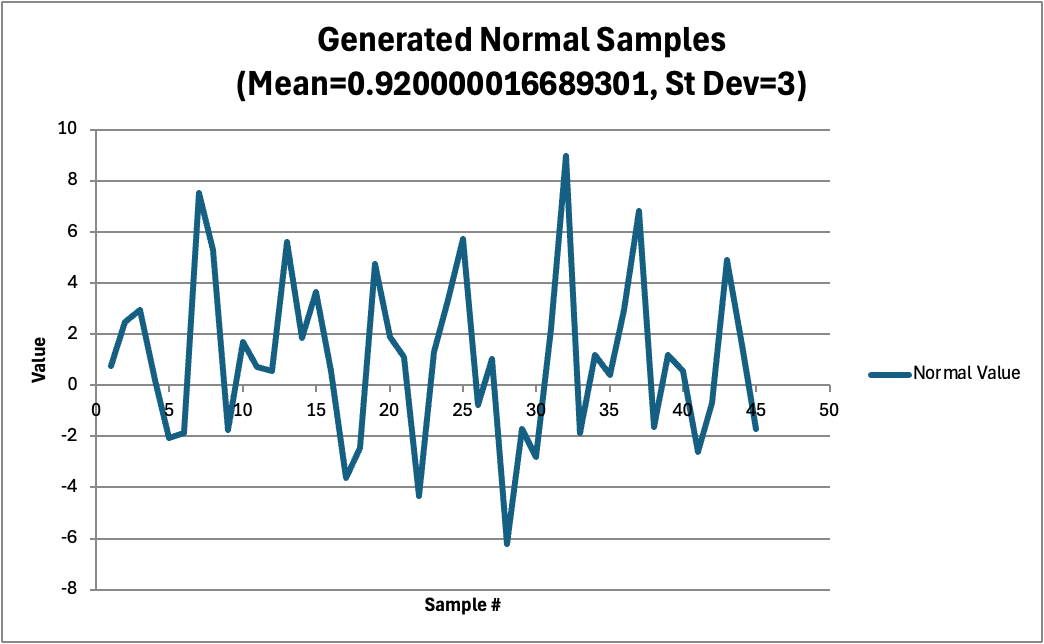

[RunResult(sample_count=45, workbook_copy=PosixPath('/Users/gitaalekhyapaul/Documents/[Local] BMD5302/bmd5302-project/notebook_outputs/workbooks/Test.xlsm'), chart_path=PosixPath('/Users/gitaalekhyapaul/Documents/[Local] BMD5302/bmd5302-project/notebook_outputs/charts/Test_run_01_b1_45.png'), sample_table=    Sample #  Normal Value
 0        1.0      0.771498
 1        2.0      2.464908
 2        3.0      2.965921
 3        4.0      0.220705
 4        5.0     -2.043889
 5        6.0     -1.856011
 6        7.0      7.541583
 7        8.0      5.299535
 8        9.0     -1.759988
 9       10.0      1.695152
 10      11.0      0.699909
 11      12.0      0.546335
 12      13.0      5.597905
 13      14.0      1.838997
 14      15.0      3.645670
 15      16.0      0.545484
 16      17.0     -3.642152
 17      18.0     -2.465316
 18      19.0      4.766319
 19      20.0      1.882250
 20      21.0      1.102955
 21      22.0     -4.352954
 22      23.0      1.295010
 23      24.0      3.3

In [12]:
results = workflow.run_for_inputs(sample_counts)

for result in results:
    summary = "\n".join(
        [
            f"### B1 = {result.sample_count}",
            f"- Workbook copy: `{result.workbook_copy}`",
            f"- Chart PNG: `{result.chart_path}`",
        ]
    )
    display(Markdown(summary))
    display(result.sample_table)
    display(Image(filename=str(result.chart_path)))

results